# Phase 3: Forecast model

**Question:** can we predict tomorrow's hourly count at each CBD sensor better
than a simple rule?

**Set-up (option A).** The council publishes counts once a month. On the day we
forecast, the newest count we could have is about **5 weeks old**. So every
feature built from past counts uses data at least 35 days old. Using last
week's counts in testing would make the model look better than it could ever
be in practice (leakage).

**Test period:** the last 12 months (Oct 2025 – Sep 2026). Training data starts
Oct 2024 (post-COVID only, see Phase 2).

1. Baseline
2. Model (next)

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from melbourne_foot_traffic import config, forecast

con = duckdb.connect(str(config.DB_PATH), read_only=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "lines.linewidth": 2, "font.size": 10, "figure.dpi": 110,
})

TEST = ("2025-10-01", "2026-09-30")
names = con.sql("SELECT location_id AS sensor_id, sensor_description AS name FROM sensors").df()

## 1. Baseline

**Rule:** for each sensor and hour, take the average count on the same weekday
5, 6, 7 and 8 weeks earlier. It needs no training and captures each sensor's
daily and weekly rhythm. Any model has to beat it to be worth having.

**Scores:**
- **MAE**: average error in people per hour.
- **WAPE**: total error as a share of total traffic, so busy and quiet sensors
  can be compared. 0.19 means "off by 19% of the traffic".

In [2]:
base = forecast.seasonal_baseline(con, *TEST)
cal = con.sql("SELECT date, is_holiday, holiday_name, school_term FROM calendar").df()
base = base.merge(cal, on="date", how="left")
print(f"{len(base):,} sensor-hours in the test year; baseline missing for {base.baseline.isna().sum()}")
forecast.score(base, "baseline").round(3)

156,014 sensor-hours in the test year; baseline missing for 35


,MAE,WAPE,hours
0,117.063,0.194,155979


In [3]:
forecast.score(base, "baseline", by="is_holiday").round(3)

,MAE,WAPE,hours
is_holiday,,,
False,112.995,0.187,150389
True,226.508,0.373,5590


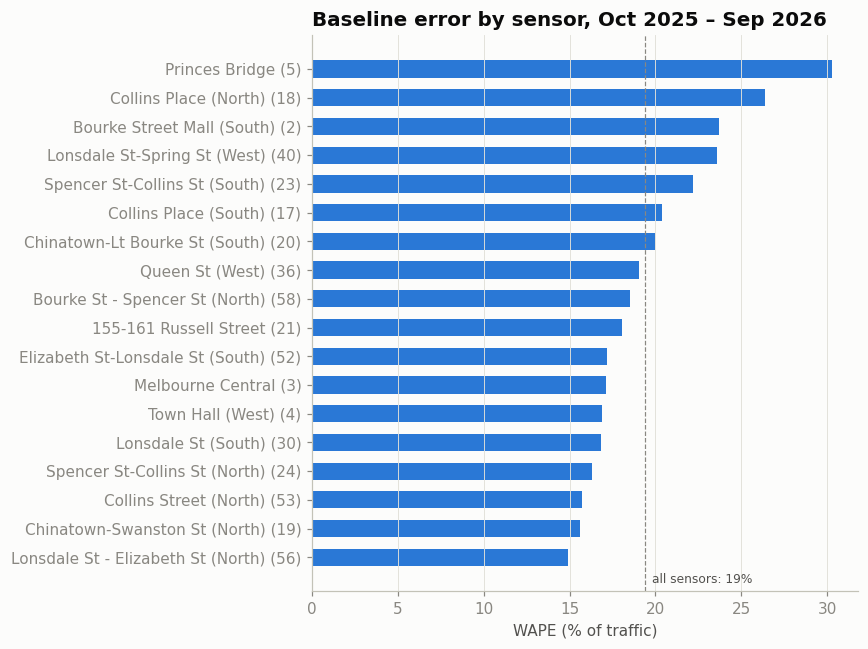

In [4]:
per_sensor = forecast.score(base, "baseline", by="sensor_id").join(names.set_index("sensor_id"))
per_sensor = per_sensor.sort_values("WAPE")

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{n} ({i})" for i, n in zip(per_sensor.index, per_sensor.name)]
ax.barh(labels, per_sensor.WAPE * 100, color=BLUE, height=0.6)
overall = forecast.score(base, "baseline").WAPE[0] * 100
ax.axvline(overall, color=MUTED, lw=0.8, ls="--")
ax.text(overall + 0.4, -0.9, f"all sensors: {overall:.0f}%", fontsize=8, color=INK2)
ax.set_xlabel("WAPE (% of traffic)")
ax.set_title("Baseline error by sensor, Oct 2025 – Sep 2026")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Where the baseline fails

The days with the largest error, with that day's weather and holiday status.
These are what the model's features need to explain.

In [5]:
wx = con.sql('''
    SELECT date, max(temperature) AS max_temp, sum(precipitation_mm) AS rain_mm
    FROM weather GROUP BY date
''').df()
daily = (base.dropna(subset=["baseline"])
         .groupby("date")
         .apply(lambda d: pd.Series({
             "actual": d["count"].sum(),
             "baseline": d.baseline.sum(),
             "WAPE": (d.baseline - d["count"]).abs().sum() / d["count"].sum(),
         }), include_groups=False)
         .reset_index()
         .merge(wx, on="date").merge(cal[["date", "holiday_name"]], on="date"))
daily["weekday"] = pd.to_datetime(daily.date).dt.day_name()
daily["actual_vs_baseline"] = (daily.actual / daily.baseline - 1).map("{:+.0%}".format)
daily.sort_values("WAPE", ascending=False).head(12)[
    ["date", "weekday", "actual_vs_baseline", "WAPE", "max_temp", "rain_mm", "holiday_name"]
].round({"WAPE": 2, "max_temp": 1, "rain_mm": 1})

,date,weekday,actual_vs_baseline,WAPE,max_temp,rain_mm,holiday_name
118,2026-01-27,Tuesday,-44%,0.82,43.4,0.0,NaN
85,2025-12-25,Thursday,-20%,0.70,16.1,0.2,Christmas Day
100,2026-01-09,Friday,-40%,0.68,43.2,0.0,NaN
98,2026-01-07,Wednesday,-38%,0.66,41.7,0.0,NaN
92,2026-01-01,Thursday,-9%,0.63,20.2,0.0,New Year's Day
38,2025-11-08,Saturday,-30%,0.56,14.4,21.6,NaN
255,2026-06-13,Saturday,-36%,0.56,17.2,8.0,NaN
246,2026-06-04,Thursday,-34%,0.52,14.2,29.8,NaN
243,2026-06-01,Monday,-29%,0.50,12.7,10.6,NaN
91,2025-12-31,Wednesday,+9%,0.48,17.3,0.5,NaN


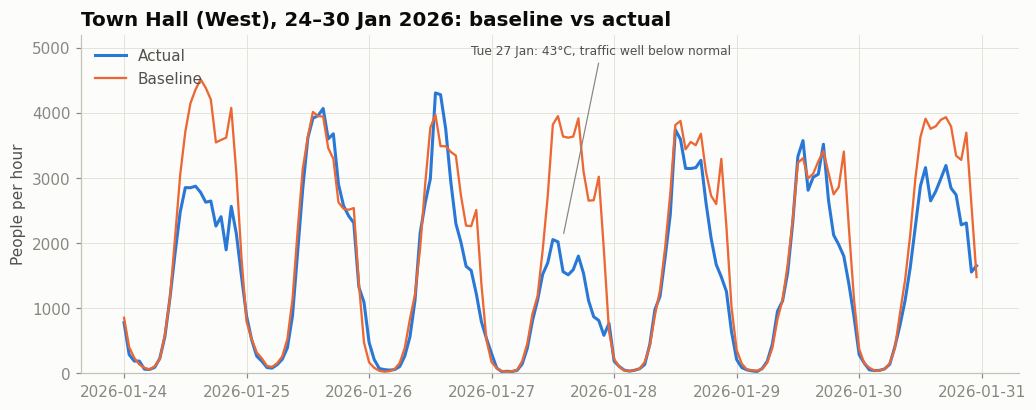

In [6]:
week = base[(base.sensor_id == 4) & (base.date.between("2026-01-24", "2026-01-30"))].copy()
week["ts"] = pd.to_datetime(week.date) + pd.to_timedelta(week.hour, unit="h")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(week.ts, week["count"], color=BLUE, label="Actual")
ax.plot(week.ts, week.baseline, color=ORANGE, label="Baseline", lw=1.5)
ax.set_ylim(0, 5200)
ax.annotate("Tue 27 Jan: 43°C, traffic well below normal", xy=(pd.Timestamp("2026-01-27 14:00"), 2100),
            xytext=(pd.Timestamp("2026-01-26 20:00"), 4900), fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_title("Town Hall (West), 24–30 Jan 2026: baseline vs actual")
ax.set_ylabel("People per hour")
ax.legend(frameon=False, loc="upper left")
plt.show()

**What the baseline misses** (and the model should learn):
- **Heat:** the four worst days of the year were all 41–43°C days in January.
- **Public holidays:** error doubles on holidays (WAPE 0.37 vs 0.19), e.g. Christmas, New Year.
- **Seasonal turns:** in early January the baseline looks back to December
  shopping weeks and over-predicts.
- **Rain:** wet June days.

## 2. Model

**LightGBM**, one model for all 18 sensors, predicting the hourly count.

**Features** (all known on the day before):
- *time*: sensor, hour, weekday, month, day of year
- *calendar*: public holiday, day before/after a holiday, school term, 6 event flags
- *weather*: temperature, feels-like, rain, humidity, cloud, wind
- *past counts* (35+ days old only): baseline, same hour 5 and 6 weeks ago, a year ago
- *season*: from 2014–2019, the typical level for this day of year, and how much
  it typically changes from 5–8 weeks earlier (e.g. ~+10% from late October to
  mid-December). This gives the model a yearly rhythm, even though recent
  data covers less than two years.

*Weather note:* training and testing use the weather that actually happened.
In real use it would be tomorrow's weather *forecast*, which is slightly less
accurate, so real-world error would be a little higher.

**How it was chosen:** set-ups were compared on Jul–Sep 2025 (before the test
year). Direct counts with all features + season features scored best (14.8% vs
baseline 15.9%). The test year was then run once with that set-up.

**How it's tested:** a rolling monthly test. Before each test month, the model is
re-trained on everything from Dec 2024 up to that month, then predicts the month
it hasn't seen. 12 rounds, Oct 2025 – Sep 2026.

In [7]:
data = forecast.build_dataset(con, "2024-12-01", TEST[1])
results = forecast.rolling_backtest(data, *TEST, train_start="2024-12-01")
results = results[results.baseline.notna()]   # compare on the same hours

summary = pd.concat({
    "Baseline": forecast.score(results, "baseline").iloc[0],
    "Model": forecast.score(results, "model").iloc[0],
}, axis=1).T
summary["WAPE"] = (summary.WAPE * 100).round(1).astype(str) + "%"
summary["MAE"] = summary.MAE.round(0)
reduction = 1 - forecast.score(results, "model").MAE[0] / forecast.score(results, "baseline").MAE[0]
print(f"The model cuts error by {reduction:.0%} vs the baseline")
summary[["MAE", "WAPE"]]

The model cuts error by 25% vs the baseline


,MAE,WAPE
Baseline,117.0,19.4%
Model,88.0,14.6%


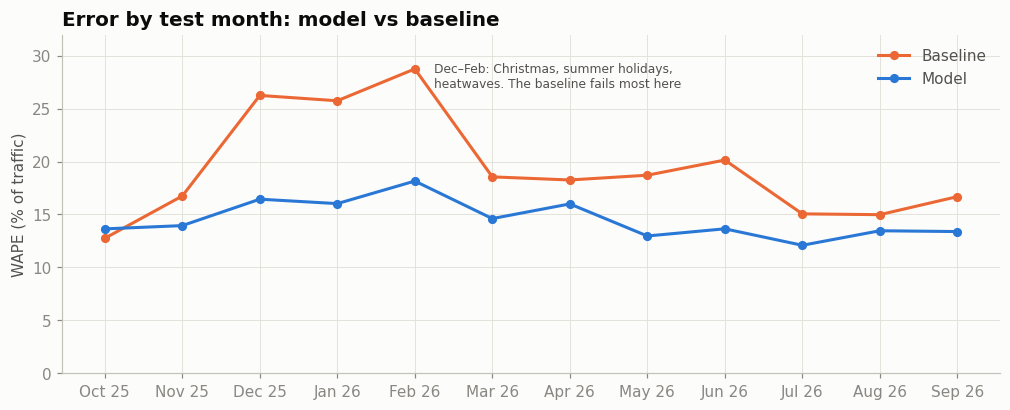

In [8]:
results["month"] = results.date.dt.to_period("M")
monthly = pd.DataFrame({
    "Baseline": forecast.score(results, "baseline", by="month").WAPE * 100,
    "Model": forecast.score(results, "model", by="month").WAPE * 100,
})
x = monthly.index.strftime("%b %y")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, monthly.Baseline, color=ORANGE, marker="o", ms=5, label="Baseline")
ax.plot(x, monthly.Model, color=BLUE, marker="o", ms=5, label="Model")
ax.set_ylim(0, 32)
ax.set_ylabel("WAPE (% of traffic)")
ax.set_title("Error by test month: model vs baseline")
ax.legend(frameon=False, loc="upper right")
ax.annotate("Dec–Feb: Christmas, summer holidays,\nheatwaves. The baseline fails most here", (4.25, 27), fontsize=8, color=INK2)
plt.show()

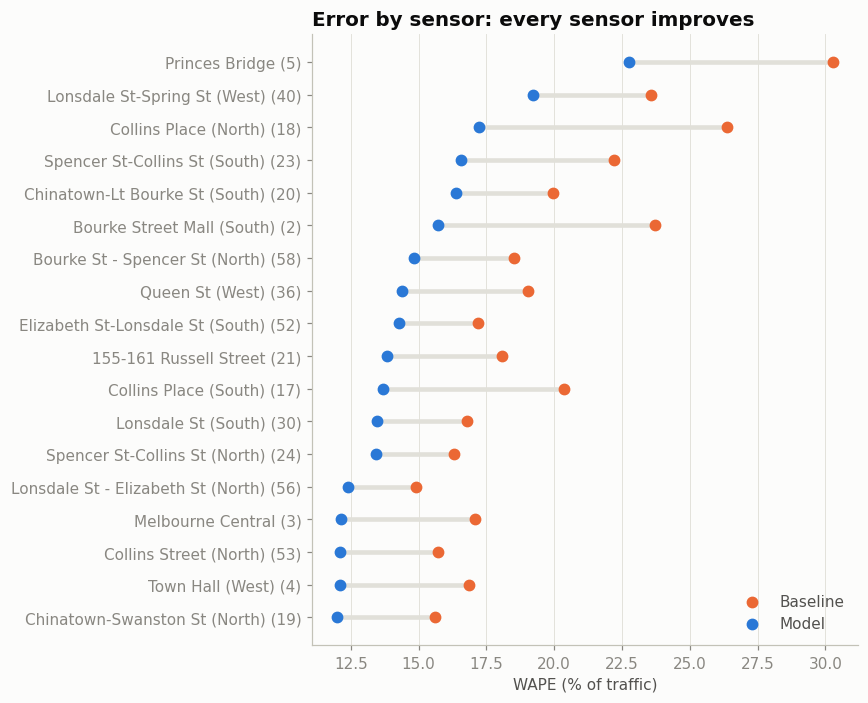

In [9]:
by = pd.DataFrame({
    "Baseline": forecast.score(results, "baseline", by="sensor_id").WAPE * 100,
    "Model": forecast.score(results, "model", by="sensor_id").WAPE * 100,
}).join(names.set_index("sensor_id")).sort_values("Model")

fig, ax = plt.subplots(figsize=(8, 6.5))
y = range(len(by))
ax.hlines(y, by.Model, by.Baseline, color=GRID, lw=3)
ax.scatter(by.Baseline, y, color=ORANGE, s=45, zorder=3, label="Baseline")
ax.scatter(by.Model, y, color=BLUE, s=45, zorder=3, label="Model")
ax.set_yticks(list(y), [f"{n} ({i})" for i, n in zip(by.index, by.name)])
ax.set_xlabel("WAPE (% of traffic)")
ax.set_title("Error by sensor: every sensor improves")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [10]:
results["day_max_temp"] = results.groupby("date").temperature.transform("max")
groups = {
    "All hours": results,
    "Normal days": results[results.is_holiday == 0],
    "Public holidays": results[results.is_holiday == 1],
    "Hot days (35°C+)": results[results.day_max_temp >= 35],
    "Rainy hours (1 mm+)": results[results.precipitation_mm >= 1],
}
pd.DataFrame({
    name: {"Baseline": forecast.score(g, "baseline").WAPE[0],
           "Model": forecast.score(g, "model").WAPE[0],
           "Hours": len(g)}
    for name, g in groups.items()
}).T.assign(Baseline=lambda d: (d.Baseline * 100).round(1), Model=lambda d: (d.Model * 100).round(1),
            Hours=lambda d: d.Hours.astype(int))

,Baseline,Model,Hours
All hours,19.4,14.6,155979
Normal days,18.7,14.2,150389
Public holidays,37.3,24.1,5590
Hot days (35°C+),47.3,25.9,2582
Rainy hours (1 mm+),41.0,26.5,4690


### Where the model still fails

In [11]:
err = results.assign(m=(results.model - results["count"]).abs(), b=(results.baseline - results["count"]).abs())
days = err.groupby("date").agg(actual=("count", "sum"), predicted=("model", "sum"), m=("m", "sum"), b=("b", "sum"),
                               max_temp=("temperature", "max"), rain_mm=("precipitation_mm", "max"),
                               holiday=("is_holiday", "max"))
days["model_WAPE"] = (days.m / days.actual).round(2)
days["baseline_WAPE"] = (days.b / days.actual).round(2)
days["model_vs_actual"] = (days.predicted / days.actual - 1).map("{:+.0%}".format)
days = days.join(cal.set_index("date").holiday_name)
days[days.actual > 10000].sort_values("model_WAPE", ascending=False).head(10)[
    ["model_vs_actual", "model_WAPE", "baseline_WAPE", "max_temp", "rain_mm", "holiday_name"]
].round({"max_temp": 1, "rain_mm": 1}).rename(columns={"rain_mm": "max_rain_mm_per_hour"})

,model_vs_actual,model_WAPE,baseline_WAPE,max_temp,max_rain_mm_per_hour,holiday_name
date,,,,,,
2026-01-27,+34%,0.39,0.82,43.4,0.0,NaN
2025-12-25,+10%,0.38,0.70,16.1,0.1,Christmas Day
2025-11-08,+22%,0.37,0.56,14.4,2.0,NaN
2025-10-26,+25%,0.35,0.35,21.0,4.9,NaN
2026-01-09,+31%,0.34,0.68,43.2,0.0,NaN
2026-02-22,-5%,0.34,0.40,27.0,2.3,NaN
2026-01-07,+31%,0.34,0.66,41.7,0.0,NaN
2026-06-13,+32%,0.34,0.56,17.2,3.1,NaN
2026-01-01,-12%,0.33,0.63,20.2,0.0,New Year's Day


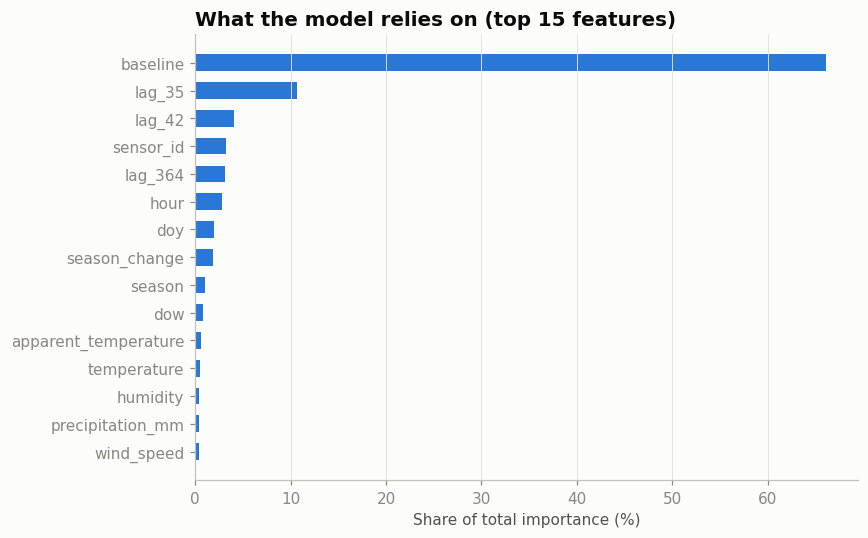

In [12]:
model = forecast.fit_predict.last_model   # the model trained for the last test month
imp = pd.Series(model.booster_.feature_importance("gain"), index=forecast.FEATURES)
imp = (imp / imp.sum() * 100).sort_values().tail(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_xlabel("Share of total importance (%)")
ax.set_title("What the model relies on (top 15 features)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 3. Result

> **The model cuts error by about 25% vs the baseline (WAPE 19.4% → 14.6%), and
> fails mostly on extreme heat (41–43°C days) and heavy-rain days**, where it still
> over-predicts by about 30%. It has only one summer of training data, so it has seen very few days
> that hot. More summers of data, or a hand-made "heatwave" feature, should help.

Other notes:
- Every one of the 18 sensors improves.
- Public holidays: error falls from 37% to 24%.
- October 2025 is the one month where the baseline wins. It's the first test
  month, when the model has the least training data (10 months).
- Feature importance: past counts do most of the work, because they set each
  sensor's normal level. Calendar and weather features have a small share
  overall, since most days are ordinary, but they are what fixes the holidays
  and hot days above.
- Context: even knowing each day's exact total in advance, hour-to-hour noise
  leaves about 13% error. So the model closes most of the gap between the
  baseline (19%) and that floor.